In [22]:
#import
import pandas as pd
import numpy as np

In [23]:
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [24]:
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [25]:
# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [26]:
# Feature selection
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
# Replace with your actual file paths
mat_path = r"C:\Users\Panha\OneDrive\Documents\student\student-mat.csv"
por_path = r"C:\Users\Panha\OneDrive\Documents\student\student-por.csv"

# Read both datasets
df_mat = pd.read_csv(mat_path, sep=';')
df_por = pd.read_csv(por_path, sep=';')

# Combine both into one DataFrame
df = pd.concat([df_mat, df_por], ignore_index=True)

# Display all columns and show the first 5 rows
pd.set_option('display.max_columns', None)
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [28]:
# We predict final grade G3 as classification
# Create binary target: Pass (>=10) / Fail (<10)
df['target'] = df['G3'].apply(lambda x: 1 if x >= 10 else 0)

In [29]:
# Drop G1 and G2 to avoid data leakage if needed
# but keep them if you want more features
X = df.drop(['G3', 'target'], axis=1)
y = df['target']

In [30]:
# --- 4. Encode Categorical Variables ---
cat_cols = X.select_dtypes(include=['object']).columns
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

In [31]:
# --- 5. Normalize Numeric Variables ---
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

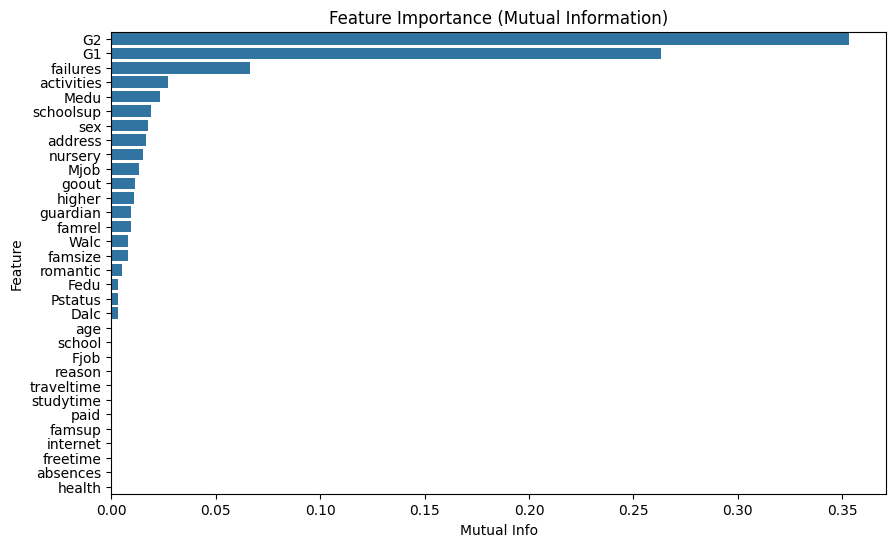

In [32]:
# --- 6. Feature Selection ---
mi_scores = mutual_info_classif(X, y)
mi_df = pd.DataFrame({'Feature': X.columns, 'Mutual Info': mi_scores})
mi_df.sort_values(by='Mutual Info', ascending=False, inplace=True)

plt.figure(figsize=(10,6))
sns.barplot(x='Mutual Info', y='Feature', data=mi_df)
plt.title('Feature Importance (Mutual Information)')
plt.show()

In [33]:

# --- 7. Split Data ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)



=== Logistic Regression ===
              precision    recall  f1-score   support

           0     0.7826    0.7826    0.7826        69
           1     0.9388    0.9388    0.9388       245

    accuracy                         0.9045       314
   macro avg     0.8607    0.8607    0.8607       314
weighted avg     0.9045    0.9045    0.9045       314


=== Decision Tree ===
              precision    recall  f1-score   support

           0     0.7258    0.6522    0.6870        69
           1     0.9048    0.9306    0.9175       245

    accuracy                         0.8694       314
   macro avg     0.8153    0.7914    0.8023       314
weighted avg     0.8654    0.8694    0.8669       314


=== Random Forest ===
              precision    recall  f1-score   support

           0     0.7761    0.7536    0.7647        69
           1     0.9312    0.9388    0.9350       245

    accuracy                         0.8981       314
   macro avg     0.8536    0.8462    0.8498       314

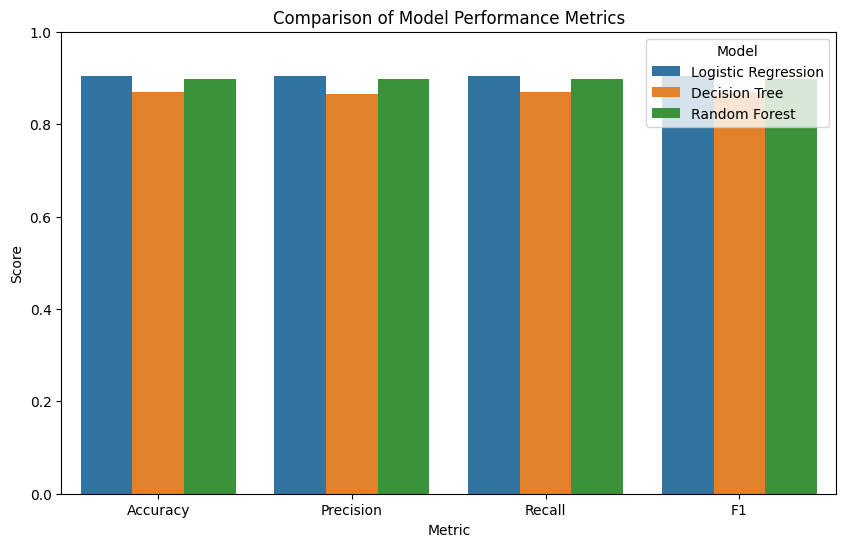

In [34]:
# --- 8. Model Training and Evaluation ---
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calculate metrics (weighted average)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append([name, acc, prec, rec, f1])

    # === Full classification report (all rows) ===
    print(f"\n=== {name} ===")
    report = classification_report(y_test, y_pred, digits=4)
    print(report)

# Create a DataFrame to compare models
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1'])
print("\nSummary of Model Performance:\n", results_df)

# --- Visual Comparison Chart ---
results_df_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
plt.figure(figsize=(10,6))
sns.barplot(x='Metric', y='Score', hue='Model', data=results_df_melted)
plt.title('Comparison of Model Performance Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(title='Model')
plt.show()


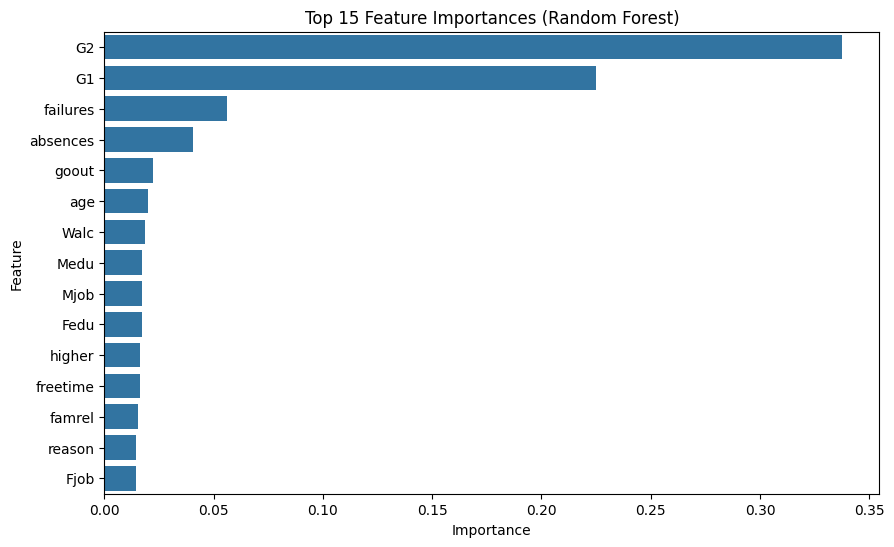

In [35]:
# --- 9. Feature Importance from Random Forest ---
rf = models['Random Forest']
feat_importance = pd.DataFrame({'Feature': X.columns,
                                'Importance': rf.feature_importances_})
feat_importance.sort_values(by='Importance', ascending=False, inplace=True)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_importance.head(15))
plt.title('Top 15 Feature Importances (Random Forest)')
plt.show()


In [36]:
# --- 10. Save Results ---
results_df.to_csv('model_performance_results.csv', index=False)